In [ ]:
#| default_exp clustering_ex

In [ ]:
#| hide
import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Clustering of Embeddings

In [ ]:
#| eval: false

from fhemb.utils.cutils import plot_dm_dendrogram, plot_clustered_dm_heatmap, dtw_clustering, depict_clusters, plot_silhouette_vs_k

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db
 [DEBUG] cutils.<module>: ROOT: /Users/radned/Projects/ttsembedding/


In [ ]:
#| eval: false

from nbdev_fhemb.wreconstruction_ex import emb_prj_decomp_rec1

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]
 [INFO] piece._load_from_db: Loading face_t fro

In [ ]:
#| eval: false
from nbdev_fhemb.module_functions_ex import Xdm

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p80
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p80
 [DEBUG] embedding.get_ts_subjs: Available features: ('p20', 'p80')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p80
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p80
 [DEBUG] embedding.get_ts_subjs: Available features: ('bh1', 'bh2', 'bh3')
 [WARNING] embedding.get_ts_subjs_ftr: Feature p80 not in features: ('bh1', 'bh2', 'bh3')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p80
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p80
 [DEBUG] embedding.get_ts_subjs: Available features: ('pc0', 'pc1', 'pc2')
 [WARNING] embedding.get_ts_subjs_ftr: Feature p80 not in features: ('pc0', 'pc1

## Cluster DTW Alignments Between Pairs of Embeddings 

In [ ]:
#| eval: false
from scipy.spatial.distance import (
    euclidean, 
    cityblock, 
    cosine, 
    mahalanobis, 
    sqeuclidean, 
    chebyshev, 
    minkowski, 
    braycurtis, 
    canberra, 
    correlation, 
    jaccard, 
    hamming
)

### Clustered heatmap
> pairwise distances whose rows and columns are reordered using hierarchical clustering, revealing similarity structure among the time series.

 [INFO] cutils.calc_dtw_dmatrix: Using cosine distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [01:15<00:00, 27.70it/s]


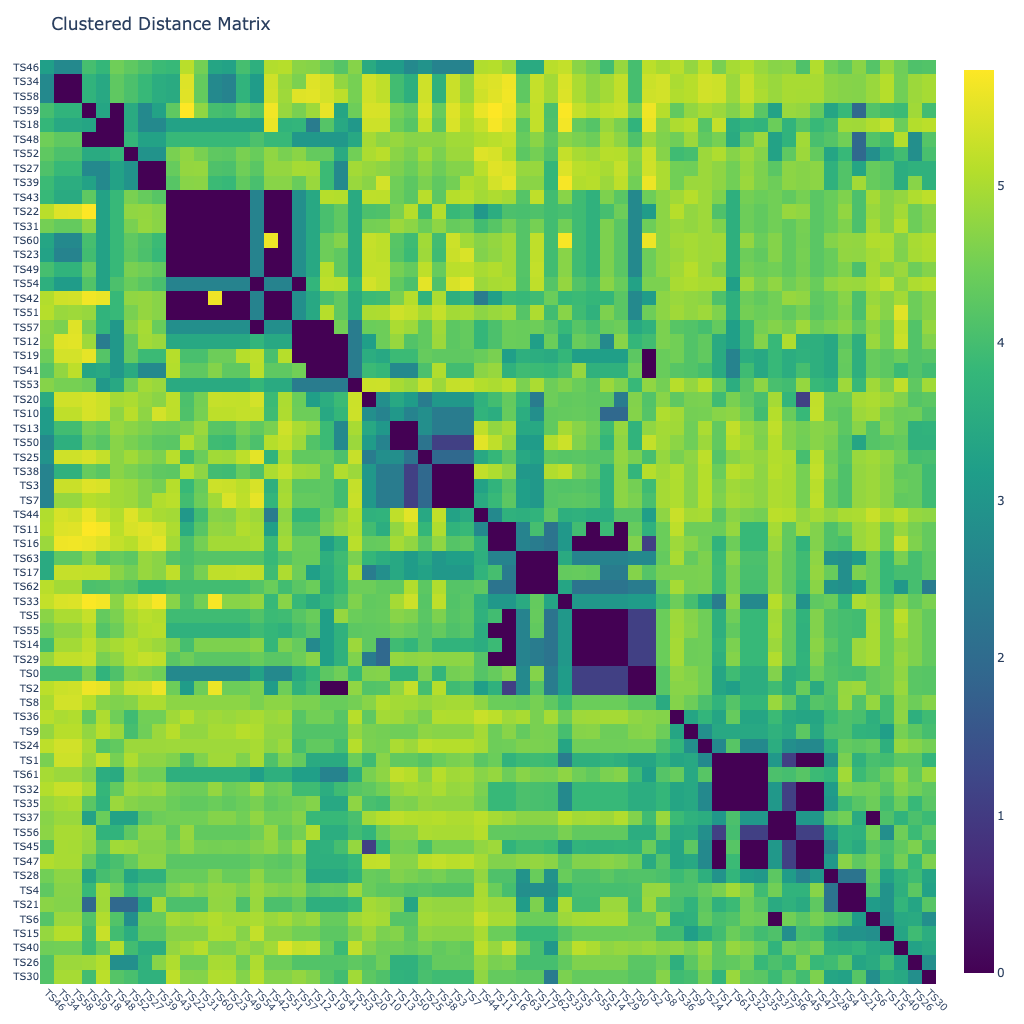

In [ ]:
#| eval: false

plot_clustered_dm_heatmap(
    Xdm,                       # data matrix (n_timeseries, n_timeseries) 
    alignment_type='fastdtw',  # 'dcor', 'fastdtw'(euclidean), 'tslearn_dtw'(euclidean), 'soft_dtw'(sqeuclidean), 'soft_dtw_div'
    dist=cosine,               # distance metric function used inside fastdtw
    radius=2,                  # refinement window size in fastdtw
    normalize='log',           # normalization method for distance matrix
    n_jobs=8,                  # number of jobs for parallelization
    base_size=16               # base pixel size
)  

### Dendrogram
> a hierarchical tree showing how time series cluster together based on their DTW‑ or dcor‑derived distances, with merge heights reflecting the distances at which clusters join.

 [INFO] cutils.calc_dtw_dmatrix: Using euclidean distance
 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 2080/2080 [00:31<00:00, 65.24it/s]


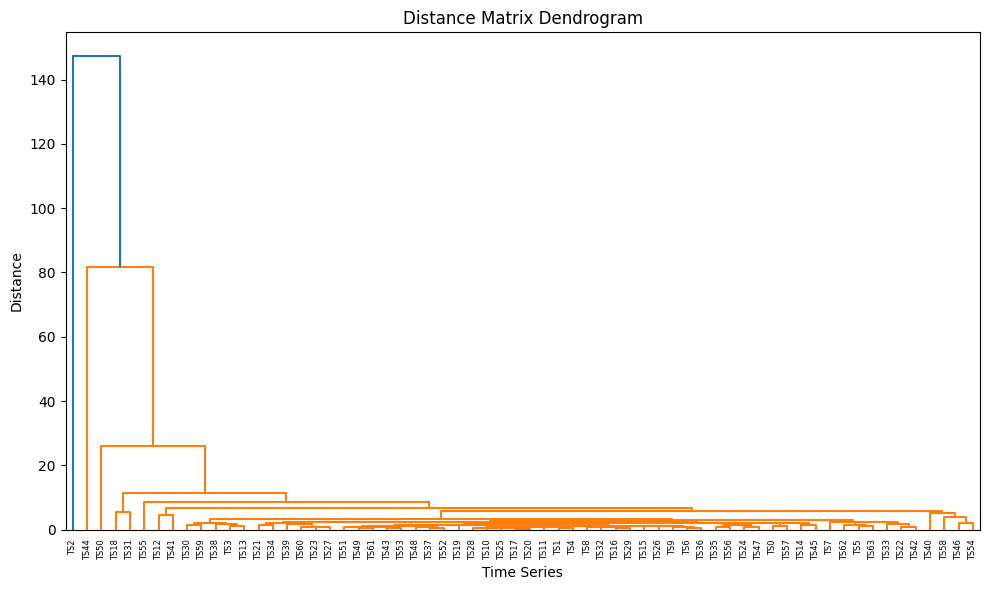

In [ ]:
#| eval: false

plot_dm_dendrogram(
    Xdm, 
    alignment_type='fastdtw', 
    gamma=10, 
    n_jobs=8
)

## Cluster Dynamics
> clustering of time series based on their DTW alignment dynamics

In [ ]:
#| eval: false

from collections import defaultdict

In [ ]:
#| eval: false
cluster_t = defaultdict(dict)

keys = [
    "clusters_subj",
    "subj_clusters",
    "labels",
    "silhouette",
    "centroids",
]

for i in [0,250,500,750]:
    _values = dtw_clustering(
        emb_prj_decomp_rec1,
        interval=(i,i+250),
        normalize=False, #'minmax',
        metric = "dtw",
        n_clusters=3,
        max_iter=10,
        random_state=10
    )

    cluster_t[i] = dict(zip(keys, _values))

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'subjects' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [INFO] cutils.dtw_clustering: No normalization applied.
 [WARNING] py.warnings._showwarnmsg: /Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

 [WARNING] py.warnings._showwarnmsg: /Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_fi

In [ ]:
#| eval: false
from nbdev_fhemb.piece_ex import dg0

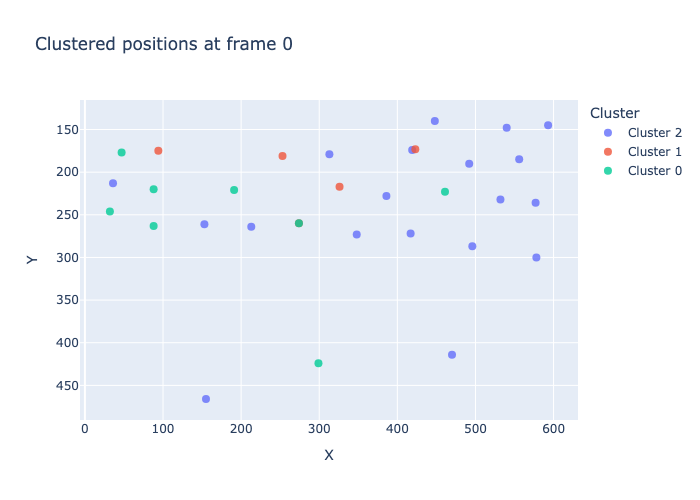

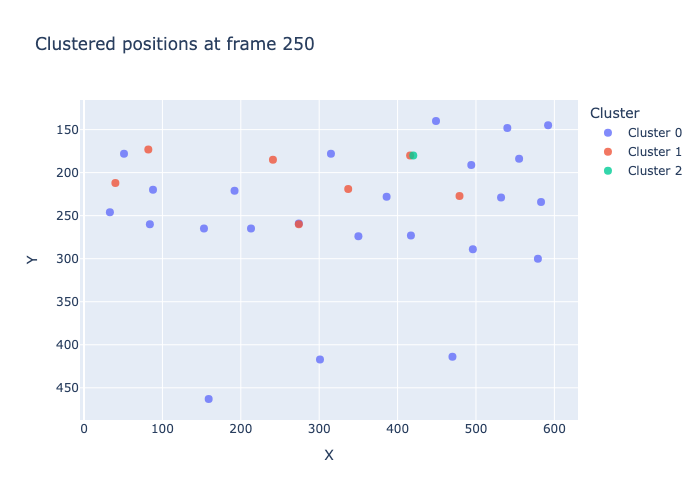

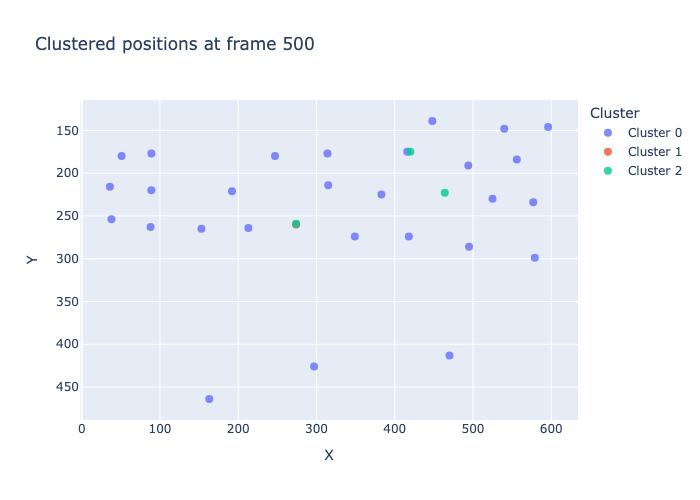

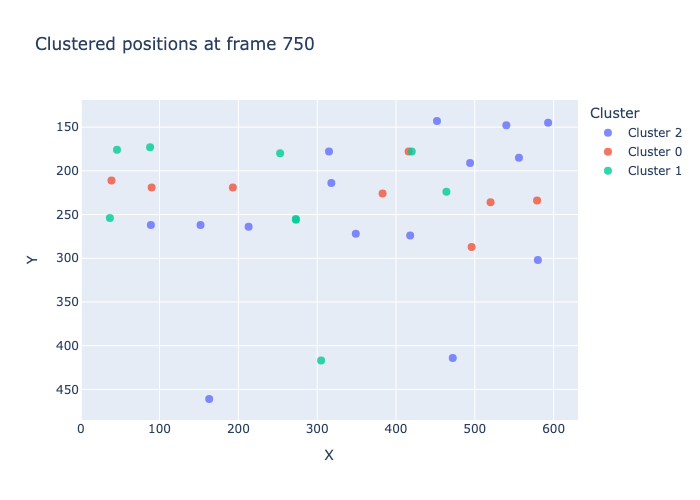

In [ ]:
#| eval: false
for frame, clusters in cluster_t.items():
    depict_clusters(
        clusters['clusters_subj'], 
        dg0.face_t.position.features_tint,
        frame=frame    
    )